In [1]:
from notebook.services.config import ConfigManager
cm = ConfigManager()
cm.update('livereveal', {
        'width': 1920,
        'height': 1080,
        'scroll': True,
})

{'width': 1920, 'height': 1080, 'scroll': True}

# Week 12 (Monday), AST 8581 / PHYS 8581 / CSCI 8581: Big Data in Astrophysics

### Michael Coughlin <cough052@umn.edu>, Michael Steinbach <stei0062@umn.edu>

With contributions totally ripped off from Dima Duev (CIT) and Lex Friedman (MIT)



# Where do we stand?

Foundations of Data and Probability -> Statistical frameworks (Frequentist vs Bayesian) -> Estimating underlying distributions -> Analysis of Time series (periodicity) -> Analysis of Time series (variability) -> Analysis of Time series (stochastic processes) -> Gaussian Processes -> Decision Trees / Regression -> Dimensionality Reduction -> Principle Component Analysis -> Clustering -> Density Estimation / Anomaly Detection -> Supervised Learning -> Deep Learning

<img src='img/fig-dl.png'>

## Practical advice from one of DL godfathers Andrej Karpathy

Highly recommended: [Andrej Karpathy's blog post](http://karpathy.github.io/2019/04/25/recipe/)

- Neural net training is a leaky abstraction

```bash
>>> your_data = # plug your awesome dataset here
>>> model = SuperCrossValidator(SuperDuper.fit, your_data, ResNet50, SGDOptimizer)
# conquer world here
```

- Neural net training fails silently

Lots of ways to screw things up -> many paths to pain and suffering

#### The recipe

- Become one with the data
    - probably, the most important and time consuming step
    - visualize as much as you can
    - check normalizations
    
    
The neural net is effectively a compressed/compiled version of your dataset, you'll be able to look at your network (mis)predictions and understand where they might be coming from. And if your network is giving you some prediction that doesn't seem consistent with what you've seen in the data, something is off.


- Set up the end-to-end training/evaluation skeleton + get dumb baselines
    - fix random seed
    - simplify
    - add significant digits to your eval
    - init well
    - fancy loss func? verify at init
    - verify decreasing training loss
    - visualize just before the net
    - active learning: check model's misclassifications, both training and testing


- Overfit: first get a model large enough that it can overfit (i.e. focus on training loss) and then regularize it appropriately (give up some training loss to improve the validation loss).
    - picking the model: don't be a hero
    - adam is safe
    - complexify only one at a time


- Regularize
    - get more data
    - data augment
    - smaller model size
    - batchnorm
    - decrease the batch size
    - use dropout
    - early stopping


- Tune
    - first prefer random over grid search
    - hyper-parameter optimization. Check out [https://github.com/keras-team/keras-tuner](keras-tuner)


- Squeeze out the juice
    - ensembles
    - leave it training


<img src='img/dl6.png'>

<img src='img/dl7.png'>

<img src='img/dl8.png'>

<img src='img/dl11.png'>

<img src='img/dl12.png'>

<img src='img/dl13.png'>

# In-class warm-up: Train a set of gravitational-wave noise transients

In [ ]:
!pip install git+https://github.com/Gravity-Spy/GravitySpy.git

  Cloning https://github.com/Gravity-Spy/GravitySpy.git to /tmp/pip-req-build-z8l2d_ht
  Running command git clone -q https://github.com/Gravity-Spy/GravitySpy.git /tmp/pip-req-build-z8l2d_ht
     |████████████████████████████████| 81kB 4.4MB/s 
     |████████████████████████████████| 1.4MB 7.5MB/s 
     |████████████████████████████████| 1.6MB 15.7MB/s 
     |████████████████████████████████| 92kB 7.0MB/s 
     |████████████████████████████████| 3.0MB 15.9MB/s 
     |████████████████████████████████| 2.3MB 27.4MB/s 
     |████████████████████████████████| 394.3MB 37kB/s 
     |████████████████████████████████| 102kB 8.1MB/s 
     |████████████████████████████████| 61kB 5.6MB/s 
     |████████████████████████████████| 61kB 6.6MB/s 
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
    Preparing wheel metadata ... done
     |████████████████████████████████| 3.2MB 38.2MB/s 
  Created wheel for redo: filename=redo-2.0.4-cp37-none-any.whl size=11931 s

In [1]:
from gwpy.table import GravitySpyTable
import pandas
import numpy
from gravityspy.utils import utils
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
from IPython.display import Image
%matplotlib inline

Using TensorFlow backend.


In [6]:
# Fetch information about glitches that were labeled by the machine learning model as being of class Scattered Light with a probability greater than 90 percent

scattered_light = GravitySpyTable.fetch('gravityspy',
                                        'glitches_public',
                                        host="gravityspyplus.ciera.northwestern.edu",
                                        user="general",
                                        passwd="generalaccess",
                                        selection=['ml_label=Scattered_Light', 'ml_confidence>0.9', "ifo=L1", "links_subjects != 1e+20"],)

blip = GravitySpyTable.fetch('gravityspy',
                                        'glitches_public',
                                        host="gravityspyplus.ciera.northwestern.edu",
                                        user="general",
                                        passwd="generalaccess",
                                        selection=['ml_label=Blip', 'ml_confidence>0.9', "ifo=L1", "links_subjects != 1e+20"],)

whistle = GravitySpyTable.fetch('gravityspy',
                                        'glitches_public',
                                        host="gravityspyplus.ciera.northwestern.edu",
                                        user="general",
                                        passwd="generalaccess",
                                        selection=['ml_label=Whistle', 'ml_confidence>0.9', "ifo=L1", "links_subjects != 1e+20"],)

/Users/mcoughlin/opt/anaconda3/envs/ast8581/lib/python3.7/site-packages/pandas/core/apply.py:285: FutureWarning: A future version of pandas will default to `skipna=True`. To silence this warning, pass `skipna=True|False` explicitly.
  values, self.f, axis=self.axis, dummy=dummy, labels=labels


In [6]:
scattered_light[0:5]

event_time,ifo,peak_time,peak_time_ns,start_time,start_time_ns,duration,search,process_id,event_id,peak_frequency,central_freq,bandwidth,channel,amplitude,snr,confidence,chisq,chisq_dof,param_one_name,param_one_value,gravityspy_id,Air_Compressor,Blip,Chirp,Extremely_Loud,Helix,Koi_Fish,Light_Modulation,Low_Frequency_Burst,Low_Frequency_Lines,No_Glitch,None_of_the_Above,Paired_Doves,Power_Line,Repeating_Blips,Scattered_Light,Scratchy,Tomte,Violin_Mode,Wandering_Line,Whistle,ml_label,workflow,subjectset,Filename1,Filename2,Filename3,Filename4,upload_flag,1400Ripples,1080Lines,image_status,data_quality,citizen_score,url1,url2,url3,url4,links_subjects,q_value,ml_confidence,vco
float64,str2,int64,int64,int64,int64,float64,str7,int64,int64,float64,float64,float64,str16,float64,float64,int64,int64,int64,str5,float64,str10,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str15,int64,int64,str114,str114,str114,str114,float64,float64,float64,str8,str37,float64,str108,str108,str108,str108,float64,float64,float64,float64
1257848627.1875,L1,1257848627,187500000,1257848626,0,2.5,OMICRON,0,172,20.5922603607178,3981.42504882812,7938.11572265625,GDS-CALIB_STRAIN,2.27978994170766e-21,33.4376602172852,0,0,0,phase,0.98854,iUejSgBzDo,0.00104865641333163,0.00112525606527925,1.49947873069323e-05,0.0012171717826277,6.22209336142987e-05,0.00105064455419779,0.00785613805055618,0.00179291679523885,0.0716456845402718,0.000232217338634655,0.0295043792575598,2.76058708550408e-05,0.00073269271524623,0.00018049799837172,0.87548828125,2.68188614427345e-05,0.000291231932351366,0.00489901006221771,0.000607781985308975,0.00139363307971507,Scattered_Light,7767,67447,/home/gravityspy/public_html/runs/O3/uZ6k12GBwL/L1_iUejSgBzDo_spectrogram_0.5.png,/home/gravityspy/public_html/runs/O3/uZ6k12GBwL/L1_iUejSgBzDo_spectrogram_1.0.png,/home/gravityspy/public_html/runs/O3/uZ6k12GBwL/L1_iUejSgBzDo_spectrogram_2.0.png,/home/gravityspy/public_html/runs/O3/uZ6k12GBwL/L1_iUejSgBzDo_spectrogram_4.0.png,1.0,0.000146321253851056,0.000655837648082525,testing,no_flag,0.0,https://panoptes-uploads.zooniverse.org/production/subject_location/c032b02e-985b-4b76-9a07-d2e7f86085d8.png,https://panoptes-uploads.zooniverse.org/production/subject_location/98decb5d-1262-4457-aa74-5a86a36d54a2.png,https://panoptes-uploads.zooniverse.org/production/subject_location/201d8a00-a893-4066-b3e1-1f7898921109.png,https://panoptes-uploads.zooniverse.org/production/subject_location/6082e5a6-12f3-4edb-8449-406ca2c9ce68.png,38145052.0,45.254833995939,0.9830797910690308,1e+20
1257857481.6875,L1,1257857481,687500000,1257857480,875000000,1.75,OMICRON,0,181,31.0353698730469,2338.78466796875,4657.5693359375,GDS-CALIB_STRAIN,1.50702005714828e-22,8.27892971038818,0,0,0,phase,-1.32149,r3UEVSqr5s,0.000525581941474229,9.10286689759232e-06,7.20111415830615e-07,5.89432493143249e-05,0.000101220168289728,0.000222265429329127,0.000288932438706979,0.00176390667911619,0.00107623788062483,4.5674303692067e-05,0.000588849012274295,1.87146524694981e-05,6.03821808908833e-06,4.87669467474916e-06,0.993364572525024,4.41728798250551e-06,3.64237439498538e-06,8.97344361874275e-05,1.06232855614508e-05,0.00177560292650014,Scattered_Light,7765,67446,/home/gravityspy/public_html/runs/O3/uZ6k12GBwL/L1_r3UEVSqr5s_spectrogram_0.5.png,/home/gravityspy/public_html/runs/O3/uZ6k12GBwL/L1_r3UEVSqr5s_spectrogram_1.0.png,/home/gravityspy/public_html/runs/O3/uZ6k12GBwL/L1_r3UEVSqr5s_spectrogram_2.0.png,/home/gravityspy/public_html/runs/O3/uZ6k12GBwL/L1_r3UEVSqr5s_spectrogram_4.0.png,1.0,3.49223023476952e-06,3.68726578017231e-05,testing,no_flag,0.0,https://panoptes-uploads.zooniverse.org/production/subject_location/166c35fb-d354-42cd-a08b-a0cee042f18a.png,https://panoptes-uploads.zooniverse.org/production/subject_location/6bbb8763-1b41-4ebb-b00e-a38ef81bd6e9.png,https://panoptes-uploads.zooniverse.org/production/subject_location/692ede60-ca7

In [7]:
# Download five scattered light, blips and whistles example of one of these images
scattered_light[0:5].download(nproc=1)
blip[0:5].download(nproc=1)
whistle[0:5].download(nproc=1)

/Users/mcoughlin/opt/anaconda3/envs/ast8581/lib/python3.7/site-packages/gwpy/table/gravityspy.py:154: FutureWarning: Method .as_matrix will be removed in a future version. Use .values instead.
  images_for_download_ext = images_for_download_ext.as_matrix(


In [8]:
# We have downloaded some PNGs into ./download, on the left under files you should see the new folder
# lets see what it looks like!
os.listdir("download")[0:4]

['L1_r3UEVSqr5s_spectrogram_1.0.png',
 'L1_iUejSgBzDo_spectrogram_1.0.png',
 'L1_Bf09uarKBg_spectrogram_1.0.png',
 'L1_mMyyLACK7X_spectrogram_4.0.png']

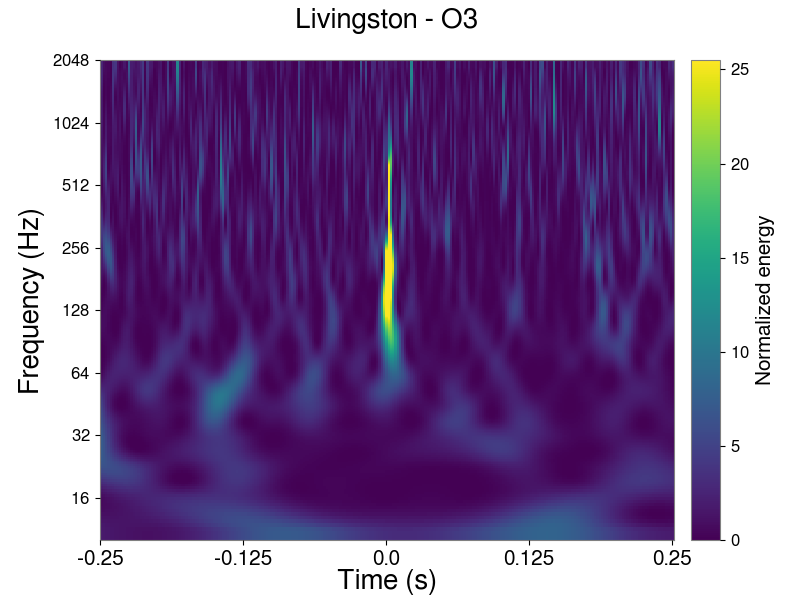

In [9]:
# Blip
Image("./download/L1_{0}_spectrogram_0.5.png".format(blip[0:1]["gravityspy_id"][0]))

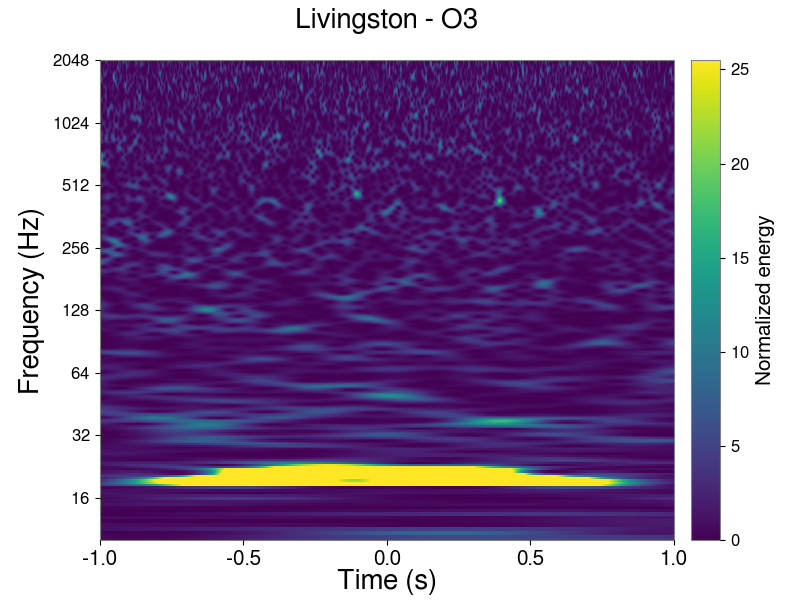

In [10]:
# Scattered_Light
Image("./download/L1_{0}_spectrogram_2.0.png".format(scattered_light[0:1]["gravityspy_id"][0]))

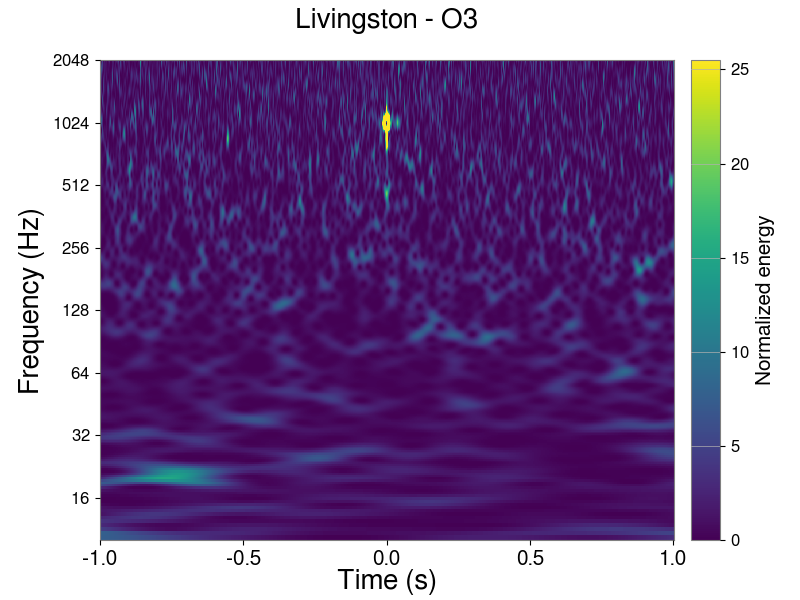

In [11]:
# Whistle
Image("./download/L1_{0}_spectrogram_2.0.png".format(whistle[0:1]["gravityspy_id"][0]))

# Scattered Light
![](/content/download/L1_7jxQwoUCx0_spectrogram_4.0.png)


In [13]:
# convert to a pandas data frame for easier data manipulation
scattered_light_df = scattered_light.to_pandas()

In [14]:
from gwpy.time import from_gps

In [15]:
scattered_light_df["event_time_calendar"] = scattered_light_df["event_time"].apply(from_gps)

In [16]:
print(scattered_light_df["event_time_calendar"].min())
print(scattered_light_df["event_time_calendar"].max())

2015-09-27 21:42:38.687500
2020-03-23 15:11:45.687500


# Download the Gravity Spy model

In [2]:
# pass a folder containing the images and the full path to where the trained model weights live
original_O3_label = utils.label_q_scans('download', path_to_cnn='data/original-O3-model.hdf5')
new_O3_label = utils.label_q_scans('download', path_to_cnn='data/updated-O3-model.hdf5')

In [3]:
# These are the labels from the original O3 model
print(original_O3_label["ml_label", "ml_confidence", "gravityspy_id"])

      ml_label      ml_confidence gravityspy_id
------------------- ------------- -------------
    Scattered_Light    0.48912087    5GwdpS1SRT
               Blip     0.9794383    6nV88vvSAS
            Whistle     0.9454994    8MMBlyhIoO
Low_Frequency_Lines     0.3643925    BDucWN3QYF
               Blip    0.98968494    Bf09uarKBg
            Whistle     0.9164153    FXrUm8Uiop
        Violin_Mode     0.9995345    KFjq2LUkne
               Blip     0.8328093    KFrEkHNaQw
            Whistle     0.5014482    MrB9hKfYkq
               Blip     0.9897746    O2HCGAQ2zk
               Blip     0.9347421    OAglNIygH6
    Scattered_Light     0.9335256    iUejSgBzDo
        Violin_Mode    0.79277706    mMyyLACK7X
    Scattered_Light    0.26160523    r3UEVSqr5s
    Scattered_Light    0.98311734    uRN1J4fw58


In [4]:
# These are the labels from the new O3 model
print(new_O3_label["ml_label", "ml_confidence", "gravityspy_id"])

    ml_label    ml_confidence gravityspy_id
--------------- ------------- -------------
Scattered_Light     0.9229292    5GwdpS1SRT
           Blip     0.9983929    6nV88vvSAS
        Whistle     0.9992717    8MMBlyhIoO
Scattered_Light    0.99493754    BDucWN3QYF
           Blip    0.99974304    Bf09uarKBg
        Whistle      0.987147    FXrUm8Uiop
        Whistle     0.9429922    KFjq2LUkne
           Blip     0.9911556    KFrEkHNaQw
        Whistle      0.999933    MrB9hKfYkq
           Blip    0.99639064    O2HCGAQ2zk
           Blip    0.99953413    OAglNIygH6
Scattered_Light    0.98307955    iUejSgBzDo
        Whistle    0.99648225    mMyyLACK7X
Scattered_Light    0.99964774    r3UEVSqr5s
Scattered_Light    0.92499346    uRN1J4fw58


In [7]:
# These are the classifications and confidence values from the glitch table
print(scattered_light[0:5]["ml_label", "ml_confidence", "gravityspy_id"])
print(blip[0:5]["ml_label", "ml_confidence", "gravityspy_id"])
print(whistle[0:5]["ml_label", "ml_confidence", "gravityspy_id"])

    ml_label      ml_confidence    gravityspy_id
--------------- ------------------ -------------
Scattered_Light 0.9830797910690308    iUejSgBzDo
Scattered_Light 0.9996477365493774    r3UEVSqr5s
Scattered_Light 0.9249916672706604    uRN1J4fw58
Scattered_Light  0.922931432723999    5GwdpS1SRT
Scattered_Light  0.994937539100647    BDucWN3QYF
ml_label   ml_confidence    gravityspy_id
-------- ------------------ -------------
    Blip 0.9983929991722107    6nV88vvSAS
    Blip 0.9997429251670837    Bf09uarKBg
    Blip  0.991156816482544    KFrEkHNaQw
    Blip 0.9995342493057251    OAglNIygH6
    Blip 0.9963909983634949    O2HCGAQ2zk
ml_label   ml_confidence    gravityspy_id
-------- ------------------ -------------
 Whistle    0.9992715716362    8MMBlyhIoO
 Whistle 0.9964820146560669    mMyyLACK7X
 Whistle 0.9871477484703064    FXrUm8Uiop
 Whistle 0.9999330043792725    MrB9hKfYkq
 Whistle 0.9429954290390015    KFjq2LUkne


# Train a model

In [8]:
from keras.utils import np_utils

# Load in the training set data that is in the form of a pickle file
trainingset_df = pandas.read_pickle("data/50_images_each_class.pkl")

# randomly shuffle the training data
trainingset_df = trainingset_df.sample(n=len(trainingset_df))

# convert class names to integers

classes = dict(enumerate(sorted(trainingset_df.true_label.unique())))
classes = dict((str(v),k) for k,v in classes.items())

trainingset_df["true_label_integer"] = trainingset_df.true_label.apply(lambda x: classes[x])

# We need to take the numpy array and reshape it into 
# (N samples, width (of each samples), height (of each sample), number of features each samples has)
img_rows =140
img_cols = 170
reshape_order = (-1, img_rows, img_cols, 1)
training_data = numpy.vstack(trainingset_df["1.0.png"]).reshape(reshape_order)

# convert integer labels to a categorical matrix.
trainingset_labels = numpy.vstack(trainingset_df.true_label_integer.values)

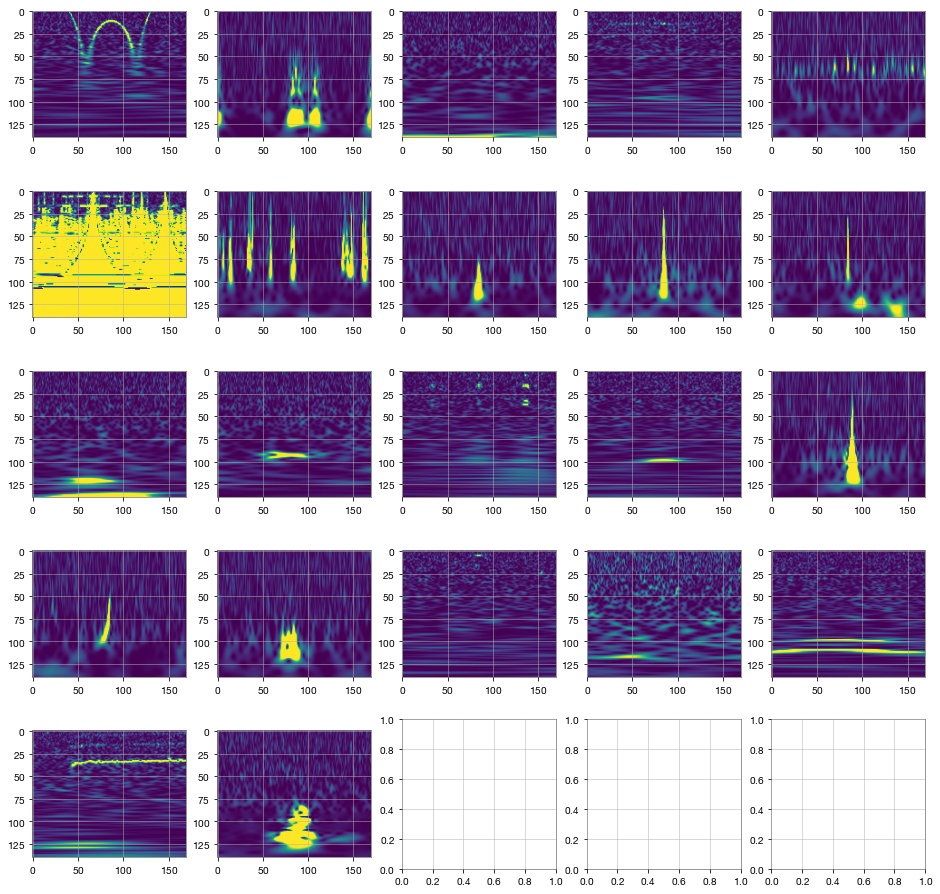

In [9]:
# Display an example of each class
from matplotlib import pyplot

fig, axes =  pyplot.subplots(5, 5, figsize=(16,16))

for class_name, ax  in zip(trainingset_df.true_label.unique(), axes.flatten()):
  class_idx = numpy.where(trainingset_df["true_label"] == class_name)[0][0]
  ax.imshow(training_data[class_idx, :, :, 0])

In [10]:
# Create a model
from tensorflow.keras import layers, models
import tensorflow as tf

model = models.Sequential()
model.add(layers.Conv2D(16, (5, 5), activation='relu', input_shape=training_data.shape[1:]))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(16, (5, 5), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(32, (5, 5), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(trainingset_df.true_label.unique().size, activation='softmax'))

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 136, 166, 16)      416       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 68, 83, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 64, 79, 16)        6416      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 32, 39, 16)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 28, 35, 32)        12832     
_________________________________________________________________
flatten (Flatten)            (None, 31360)             0         
_________________________________________________________________
dense (Dense)                (None, 32)                1

In [11]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


history = model.fit(training_data, trainingset_labels, epochs=10, 
                    validation_split=0.1, batch_size=100,)

Train on 962 samples, validate on 107 samples
Epoch 1/10
962/962 [==============================] - 38s 40ms/sample - loss: 3.0743 - accuracy: 0.0748 - val_loss: 3.0356 - val_accuracy: 0.1028
Epoch 2/10
962/962 [==============================] - 38s 39ms/sample - loss: 2.9827 - accuracy: 0.1881 - val_loss: 2.8962 - val_accuracy: 0.2804
Epoch 3/10
962/962 [==============================] - 34s 35ms/sample - loss: 2.8473 - accuracy: 0.3202 - val_loss: 2.8833 - val_accuracy: 0.2710
Epoch 4/10
962/962 [==============================] - 24s 25ms/sample - loss: 2.8293 - accuracy: 0.3316 - val_loss: 2.8497 - val_accuracy: 0.2991
Epoch 5/10
962/962 [==============================] - 21s 22ms/sample - loss: 2.7997 - accuracy: 0.3597 - val_loss: 2.8000 - val_accuracy: 0.3832
Epoch 6/10
962/962 [==============================] - 26s 27ms/sample - loss: 2.7511 - accuracy: 0.4200 - val_loss: 2.7618 - val_accuracy: 0.4019
Epoch 7/10
962/962 [==============================] - 21s 22ms/sample - loss: 

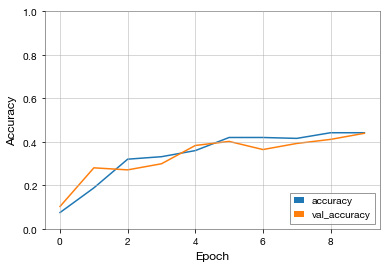

In [12]:
from matplotlib import pyplot
pyplot.plot(history.history['accuracy'], label='accuracy')
pyplot.plot(history.history['val_accuracy'], label = 'val_accuracy')
pyplot.xlabel('Epoch')
pyplot.ylabel('Accuracy')
pyplot.ylim([0, 1])
pyplot.legend(loc='lower right')

#test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)


# In-class Exercise: Real-bogus classification for the Zwicky Transient Facility (ZTF) using deep learning

## Efficient automated detection of flux-transient, reoccurring flux-variable, and moving objects is increasingly important for large-scale astronomical surveys.

* Events observed by ZTF may have been triggered from a flux-transient, a reoccurring flux-variable, or a moving object. The metadata and contextual information including the cutouts are put into "alert packets" that are distributed via the ZTF Alert Distribution System (ZADS). On a typical night, the number of detected events ranges from $10^5 - 10^6$.

<img src='img/fig-ztf_alerts.png'>

* The real/bogus ($rb$) machine learning (ML) classifiers are designed to separate genuine astrophysical events from bogus detections by scoring individual sources on a scale from 0.0 (bogus) to 1.0 (real). Currently, ZTF employs two $rb$ classifiers: a feature-based random forest classifier ($rfrb$), and `braai` a convolutional-neural-network, deep-learning classifier.
* In this tutorial, we will build a deep $rb$ classifier based on `braai`. We will use a data set consisting of $11.5k$ labeled alerts from the [ZTF public alert stream](https://ztf.uw.edu/alerts/public/).
* For further details on `braai` please refer to For details, please see [Duev+ 2019, MNRAS, 489, 3582](https://academic.oup.com/mnras/article/489/3/3582/5554758) or [arXiv:1907.11259](https://arxiv.org/pdf/1907.11259.pdf).

### Imports

In [13]:
from IPython.display import HTML, display
import tqdm
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.model_selection import train_test_split
import datetime
from astropy.time import Time

import os
import io
import gzip
from astropy.io import fits
from bson.json_util import loads, dumps

import matplotlib.pyplot as plt
# plt.style.use(['dark_background'])
from pandas.plotting import register_matplotlib_converters, scatter_matrix
register_matplotlib_converters()
%matplotlib inline

### Data set

Download from `skipper` if necessary:

In [14]:
!wget -O candidates.csv https://storage.googleapis.com/dmitryduev/braai.candidates.programid1.csv
!wget -O https://storage.googleapis.com/dmitryduev/braai.triplets.norm.programid1.npy
!ls

--2021-03-27 14:51:15--  https://storage.googleapis.com/dmitryduev/braai.candidates.programid1.csv
Resolving storage.googleapis.com (storage.googleapis.com)... 2607:f8b0:4009:816::2010, 2607:f8b0:4009:815::2010, 2607:f8b0:4009:813::2010, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|2607:f8b0:4009:816::2010|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16585888 (16M) [application/octet-stream]
Saving to: ‘candidates.csv’

candidates.csv      100%[===================>]  15.82M  31.0MB/s    in 0.5s    

2021-03-27 14:51:16 (31.0 MB/s) - ‘candidates.csv’ saved [16585888/16585888]

wget: missing URL
Usage: wget [OPTION]... [URL]...

Try `wget --help' for more options.
candidates.csv           download                 lecture21.ipynb
data                     img                      lecture21_solution.ipynb


#### Candidates

First load the $csv$ file containing the `candidate` block of the alerts (cutouts and previous detections are excluded). All alerts are labeled (0=bogus, 1=real).

In [15]:
df = pd.read_csv('data/candidates.csv')
display(df)
df.info()
df.describe()

,Unnamed: 0,aimage,aimagerat,bimage,bimagerat,candid,chinr,chipsf,classtar,clrcoeff,...,szmag1,szmag2,szmag3,tblid,tooflag,xpos,ypos,zpclrcov,zpmed,label
0,0,1.051,0.308211,0.991,0.290616,737414800515015021,3.024,1.074084,0.953,0.090182,...,19.752300,18.349100,19.709101,21,0,1102.627808,2502.003174,-0.000003,26.278999,1
1,1,0.911,0.283801,0.877,0.273209,548211733715015007,0.895,1.868645,0.921,NaN,...,18.470301,20.777000,20.725700,7,0,2904.806396,280.736298,NaN,NaN,1
2,2,0.802,0.586078,0.669,0.488886,527282584015015018,2.373,1.259607,0.876,NaN,...,17.358500,-999.000000,-999.000000,18,0,1045.247070,2085.618652,NaN,NaN,1
3,3,0.708,0.534324,0.673,0.507909,540383446315015002,0.217,5.922930,0.992,NaN,...,14.093500,19.026699,20.882000,2,0,279.002289,381.362091,NaN,NaN,1
4,4,0.927,0.317466,0.881,0.301712,806286202415015004,3.389,3.200528,0.983,-0.080435,...,20.331200,20.488501,-999.000000,4,0,1296.672852,861.606018,-0.000052,26.166000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11551,11551,1.833,0.385895,1.189,0.250316,739458591615010002,0.721,7.560311,0.977,0.096468,...,21.166901,-999.000000,20.226500,2,0,77.071404,2386.187988,-0.000008,26.271000,0
11552,11552,0.543,0.316860,0.407,0.237499,757172973715015018,1.217,110.132088,0.996,-0.027756,...,11.218000,-999.000000,15.170200,18,0,2392.119385,1160.997314,-0.000008,26.139000,0
11553,11553,0.786,0.241104,0.687,0.210736,760143561415015025,3.879,3.974642,0.950,0.077196,...,18.407200,19.270201,12.458000,25,0,2683.692627,623.401001,-0.000005,26.049999,0
11554,11554,1.448,0.218401,1.078,0.162594,786157411215015113,0.579,6.098668,0.110,-0.078874,...,19.115700,11.614000,14.894300,113,0,1652.860962,2199.916748,-0.000017,26.172001,0


TypeError: Cannot interpret '<attribute 'dtype' of 'numpy.generic' objects>' as a data type

In [16]:
print(f'num_bogus: {np.sum(df.label == 0)}')
print(f'num_real: {np.sum(df.label == 1)}')

num_bogus: 3564
num_real: 7992


#### Cutout images

In [17]:
def make_triplet(alert, normalize: bool = False, to_tpu: bool = False):
    """
        Feed in alert packet
    """
    cutout_dict = dict()

    for cutout in ('science', 'template', 'difference'):
        cutout_data = loads(dumps([alert[f'cutout{cutout.capitalize()}']['stampData']]))[0]

        # unzip
        with gzip.open(io.BytesIO(cutout_data), 'rb') as f:
            with fits.open(io.BytesIO(f.read())) as hdu:
                data = hdu[0].data
                # replace nans with zeros
                cutout_dict[cutout] = np.nan_to_num(data)
                # normalize
                if normalize:
                    cutout_dict[cutout] /= np.linalg.norm(cutout_dict[cutout])

        # pad to 63x63 if smaller
        shape = cutout_dict[cutout].shape
        if shape != (63, 63):
            # print(f'Shape of {candid}/{cutout}: {shape}, padding to (63, 63)')
            cutout_dict[cutout] = np.pad(cutout_dict[cutout], [(0, 63 - shape[0]), (0, 63 - shape[1])],
                                         mode='constant', constant_values=1e-9)

    triplet = np.zeros((63, 63, 3))
    triplet[:, :, 0] = cutout_dict['science']
    triplet[:, :, 1] = cutout_dict['template']
    triplet[:, :, 2] = cutout_dict['difference']
    
    if to_tpu:
        # Edge TPUs require additional processing
        triplet = np.rint(triplet * 128 + 128).astype(np.uint8).flatten()
    
    return triplet

We will now load pre-processed image cutout triplets: [epochal science image, reference image, ZOGY difference image]. The ZTF cutout images are centered on the event candidate and are of size 63x63 pixels (or smaller, if the event is detected near the CCD edge) at a plate scale of 1$"$ per pixel. We perform independent $L^2$-normalization of the epochal science, reference, and difference cutouts and stack them to form 63x63x3 triplets that are input into the model. Smaller examples are accordingly padded using a constant pixel value of $10^{-9}$. See function `make_triplet` above.

In [18]:
# We will use memory mapping as the file is relatively large (1 GB)
triplets = np.load('data/triplets.norm.npy', mmap_mode='r')

FileNotFoundError: [Errno 2] No such file or directory: 'data/triplets.norm.npy'

#### Visuals

Plot a few triplet examples:

candid: 793168855315010009, label: 1


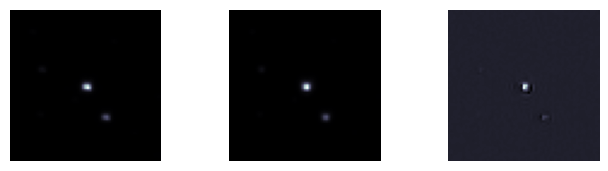

candid: 592379620715015062, label: 0


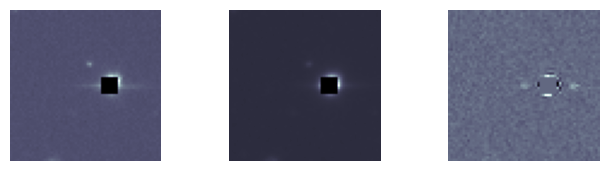

candid: 789366042815015013, label: 1


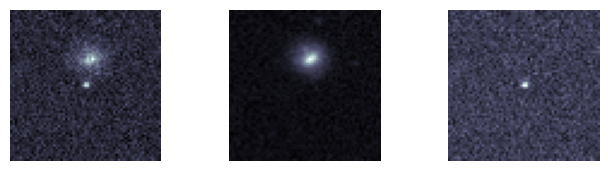

candid: 721142871415015004, label: 1


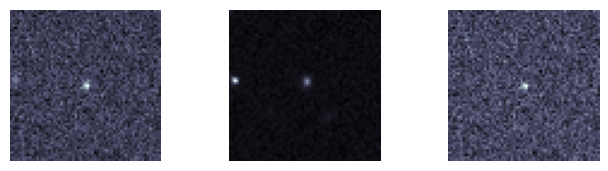

candid: 609197004715015005, label: 1


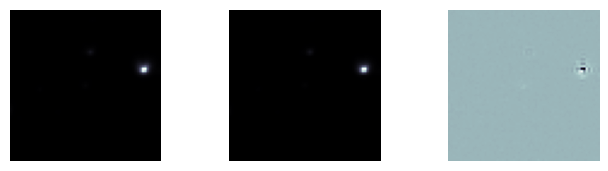

In [8]:
ind = np.random.randint(0, high=len(df), size=5)
for ii in ind:
    print(f'candid: {df.loc[ii, "candid"]}, label: {df.loc[ii, "label"]}')
    fig = plt.figure(figsize=(8, 2), dpi=100)
    triplet = triplets[ii, :]
    ax = fig.add_subplot(131)
    ax.axis('off')
    ax.imshow(triplet[:, :, 0], origin='lower', cmap=plt.cm.bone)
    ax2 = fig.add_subplot(132)
    ax2.axis('off')
    ax2.imshow(triplet[:, :, 1], origin='lower', cmap=plt.cm.bone)
    ax3 = fig.add_subplot(133)
    ax3.axis('off')
    ax3.imshow(triplet[:, :, 2], origin='lower', cmap=plt.cm.bone)
    plt.show()

Let's explore the dataset a little bit:

/Users/mcoughlin/opt/anaconda3/envs/ast8581/lib/python3.7/site-packages/ipykernel_launcher.py:12: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared
  if sys.path[0] == '':
/Users/mcoughlin/opt/anaconda3/envs/ast8581/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:307: MatplotlibDeprecationWarning: 
The rowNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().rowspan.start instead.
  layout[ax.rowNum, ax.colNum] = ax.get_visible()
/Users/mcoughlin/opt/anaconda3/envs/ast8581/lib/python3.7/site-packages/pandas/plotting/_matplotlib/tools.py:307: MatplotlibDeprecationWarning: 
The colNum attribute was deprecated in Matplotlib 3.2 and will be removed two minor releases later. Use ax.get_subplotspec().colspan.start instead.
  layout[ax.rowNum, ax.colNum] = ax.get_visible()
/Users/mcoughlin/opt/anaconda3/envs/ast8581/lib/python3.7/site-packages/pandas/plotting/_matplo

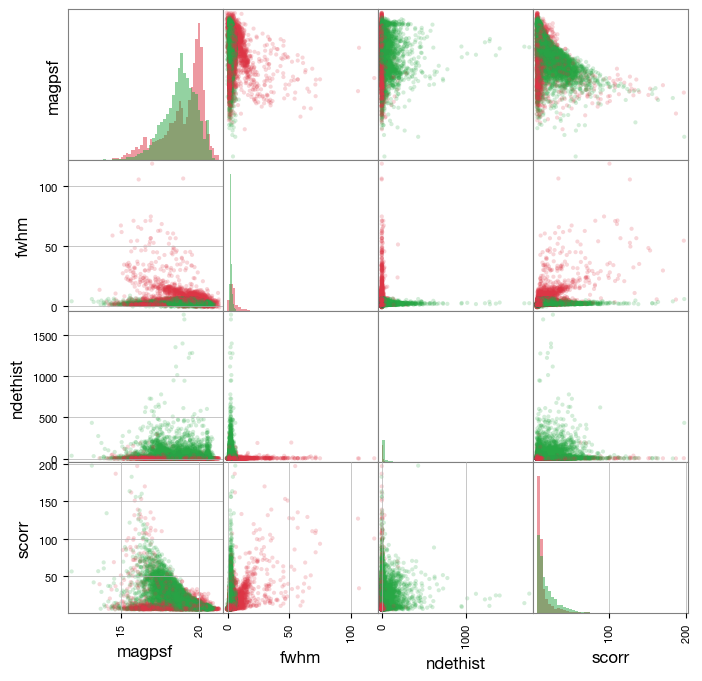

In [19]:
fig = plt.figure(figsize=(8, 8), dpi=100)
ax = fig.add_subplot(111)

color_wheel = {0: "#dc3545", 
               1: "#28a745"}
colors = df["label"].map(lambda x: color_wheel.get(x))

columns = ['magpsf', 'fwhm', 'ndethist', 'scorr']

axx = scatter_matrix(df.loc[df.label >= 0, columns], 
                     alpha=0.2,  diagonal='hist', ax=ax, grid=True, color=colors,
                     hist_kwds={'color': 'darkblue', 'alpha': 0, 'bins': 50})

for rc in range(len(columns)):
    rc_y_max = 0
    for group in color_wheel.keys():
        y = df[df.label == group][columns[rc]]
        hh = axx[rc][rc].hist(y, bins=50, alpha=0.5, color=color_wheel[group], density=1)
#         print(np.min(hh[0]), np.max(hh[0]))
        rc_y_max = max(rc_y_max, np.max(hh[0]))
        axx[rc][rc].set_ylim([0, 1.1*rc_y_max])

# scatter_matrix(df.loc[df.label == 0, ['magpsf', 'fwhm', 'ndethist']], 
#                alpha=0.2,  diagonal='hist', ax=ax,
#                hist_kwds={'color': '#dc3545', 'alpha': 0.5, 'bins': 100}, color='#dc3545')
# scatter_matrix(df.loc[df.label == 1, ['magpsf', 'fwhm', 'ndethist']], 
#                alpha=0.2,  diagonal='hist', ax=ax,
#                hist_kwds={'color': '#28a745', 'alpha': 0.5, 'bins': 100}, color='#28a745')

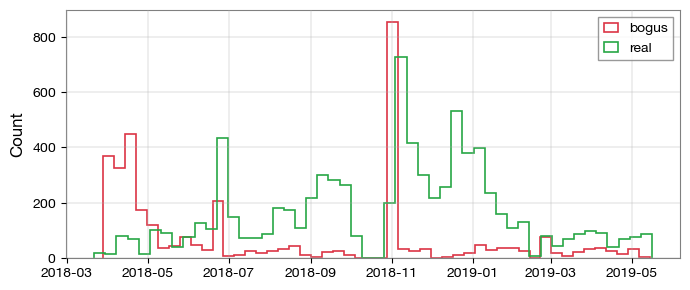

In [20]:
df['date'] = df['jd'].map(lambda x: Time(x, format='jd').datetime)
fig = plt.figure(figsize=(7, 3), dpi=100)
ax = fig.add_subplot(111)
ax.hist(df.loc[df['label'] == 0, 'date'], bins=50, #linestyle='dashed',
        color=color_wheel[0], histtype='step', label='bogus', linewidth=1.2)
ax.hist(df.loc[df['label'] == 1, 'date'], bins=50,
        color=color_wheel[1], histtype='step', label='real', linewidth=1.2)
# ax.set_xlabel('Date')
ax.set_ylabel('Count')
ax.legend(loc='best')
ax.grid(True, linewidth=.3)
plt.tight_layout()

We will use 81\% / 9\% / 10\% training/validation/test data split:

In [21]:
test_split = 0.1

# set random seed for reproducable results:
random_state = 42

x_train, x_test, y_train, y_test = train_test_split(triplets, df.label, 
                                                    test_size=test_split, random_state=random_state)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

NameError: name 'triplets' is not defined

### `braai` architecture

We will use a simple custom VGG-like sequential model ($VGG6$; this architecture was first proposed by the Visual Geometry Group of the Department of Engineering Science, University of Oxford, UK). The model has six layers with trainable parameters: four convolutional and two fully-connected. The first two convolutional layers use 16 3x3 pixel filters each while in the second pair, 32 3x3 pixel filters are used. To prevent over-fitting, a dropout rate of 0.25 is applied after each max-pooling layer and a dropout rate of 0.5 is applied after the second fully-connected layer. ReLU activation functions (Rectified Linear Unit --  a function defined as the positive part of its argument) are used for all five hidden trainable layers; a sigmoid activation function is used for the output layer.

![](img/fig-braai2.png)

In [10]:
def vgg6(input_shape=(63, 63, 3), n_classes: int = 1):
    """
        VGG6
    :param input_shape:
    :param n_classes:
    :return:
    """

    model = tf.keras.models.Sequential(name='VGG6')
    # input: 63x63 images with 3 channel -> (63, 63, 3) tensors.
    # this applies 16 convolution filters of size 3x3 each.
    model.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=input_shape, name='conv1'))
    model.add(tf.keras.layers.Conv2D(16, (3, 3), activation='relu', name='conv2'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', name='conv3'))
    model.add(tf.keras.layers.Conv2D(32, (3, 3), activation='relu', name='conv4'))
    model.add(tf.keras.layers.MaxPooling2D(pool_size=(4, 4)))
    model.add(tf.keras.layers.Dropout(0.25))

    model.add(tf.keras.layers.Flatten())

    model.add(tf.keras.layers.Dense(256, activation='relu', name='fc_1'))
    model.add(tf.keras.layers.Dropout(0.5))
    # output layer
    activation = 'sigmoid' if n_classes == 1 else 'softmax'
    model.add(tf.keras.layers.Dense(n_classes, activation=activation, name='fc_out'))

    return model

### Model training

`braai` is implemented using `TensorFlow` software and its high-level `Keras` API. We will use the binary cross-entropy loss function, the Adam optimizer, a batch size of 64, and a 81\%/9\%/10\% training/validation/test data split. The training image data are weighted per class to mitigate the real vs. bogus imbalance in the data sets. To augment the data, the images may be flipped horizontally and/or vertically at random. No random rotations and translations will be added.

In [11]:
def save_report(path: str = './', stamp: str = None, report: dict = dict()):
    f_name = os.path.join(path, f'report.{stamp}.json')
    with open(f_name, 'w') as f:
        json.dump(report, f, indent=2)

# make train and test masks:
_, _, mask_train, mask_test = train_test_split(df.label, list(range(len(df.label))),
                                                   test_size=test_split, random_state=random_state)
masks = {'training': mask_train, 'test': mask_test}

In [12]:
tf.keras.backend.clear_session()

loss = 'binary_crossentropy'
optimizer = 'adam'
epochs = 100
patience = 50
# epochs = 10
# patience = 5
validation_split = 0.1
class_weight = True
batch_size = 64

# halt training if no gain in validation accuracy over patience epochs
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience)

data_augmentation = {'horizontal_flip': True,
                     'vertical_flip': True,
                     'rotation_range': 0,
                     'fill_mode': 'constant',
                     'cval': 1e-9}
datagen = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=data_augmentation['horizontal_flip'],
                                                          vertical_flip=data_augmentation['vertical_flip'],
                                                          rotation_range=data_augmentation['rotation_range'],
                                                          fill_mode=data_augmentation['fill_mode'],
                                                          cval=data_augmentation['cval'],
                                                          validation_split=validation_split)

training_generator = datagen.flow(x_train, y_train, batch_size=batch_size, subset='training')
validation_generator = datagen.flow(x_train, y_train, batch_size=batch_size, subset='validation')

In [13]:
binary_classification = True if loss == 'binary_crossentropy' else False
n_classes = 1 if binary_classification else 2

# training data weights
if class_weight:
    # weight data class depending on number of examples?
    if not binary_classification:
        num_training_examples_per_class = np.sum(y_train, axis=0)
    else:
        num_training_examples_per_class = np.array([len(y_train) - np.sum(y_train), np.sum(y_train)])

    assert 0 not in num_training_examples_per_class, 'found class without any examples!'

    # fewer examples -- larger weight
    weights = (1 / num_training_examples_per_class) / np.linalg.norm((1 / num_training_examples_per_class))
    normalized_weight = weights / np.max(weights)

    class_weight = {i: w for i, w in enumerate(normalized_weight)}

else:
    class_weight = {i: 1 for i in range(2)}
    
# image shape:
image_shape = x_train.shape[1:]
print('Input image shape:', image_shape)

Input image shape: (63, 63, 3)


Build and compile the model:

In [14]:
model = vgg6(input_shape=image_shape, n_classes=n_classes)

# set up optimizer:
if optimizer == 'adam':
    optimzr = tf.keras.optimizers.Adam(lr=3e-4, beta_1=0.9, beta_2=0.999,
                                       epsilon=None, decay=0.0, amsgrad=False)
elif optimizer == 'sgd':
    optimzr = tf.keras.optimizers.SGD(lr=0.01, momentum=0.9, decay=1e-6, nesterov=True)
else:
    print('Could not recognize optimizer, using Adam')
    optimzr = tf.keras.optimizers.Adam(lr=3e-4, beta_1=0.9, beta_2=0.999,
                                       epsilon=None, decay=0.0, amsgrad=False)

model.compile(optimizer=optimzr, loss=loss, metrics=['accuracy'])

print(model.summary())

Model: "VGG6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1 (Conv2D)               (None, 61, 61, 16)        448       
_________________________________________________________________
conv2 (Conv2D)               (None, 59, 59, 16)        2320      
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 29, 29, 16)        0         
_________________________________________________________________
dropout (Dropout)            (None, 29, 29, 16)        0         
_________________________________________________________________
conv3 (Conv2D)               (None, 27, 27, 32)        4640      
_________________________________________________________________
conv4 (Conv2D)               (None, 25, 25, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 6, 6, 32)          0      

Train!

In [15]:
run_t_stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = f'braai_{model.name}_{run_t_stamp}'

h = model.fit_generator(training_generator,
                        steps_per_epoch=len(x_train) // batch_size,
                        validation_data=validation_generator,
                        validation_steps=(len(x_train)*validation_split) // batch_size,
                        class_weight=class_weight,
                        epochs=epochs,
                        verbose=1, callbacks=[early_stopping])

Epoch 1/100
162/162 [==============================] - 44s 274ms/step - loss: 6.3612 - accuracy: 0.6444 - val_loss: 1.0611 - val_accuracy: 0.8369
Epoch 2/100
162/162 [==============================] - 44s 271ms/step - loss: 1.4098 - accuracy: 0.7580 - val_loss: 0.8108 - val_accuracy: 0.8535
Epoch 3/100
162/162 [==============================] - 45s 276ms/step - loss: 0.7971 - accuracy: 0.7920 - val_loss: 0.5841 - val_accuracy: 0.8691
Epoch 4/100
162/162 [==============================] - 42s 258ms/step - loss: 0.5501 - accuracy: 0.8321 - val_loss: 0.4828 - val_accuracy: 0.8916
Epoch 5/100
162/162 [==============================] - 45s 276ms/step - loss: 0.4318 - accuracy: 0.8510 - val_loss: 0.4076 - val_accuracy: 0.9043
Epoch 6/100
162/162 [==============================] - 44s 269ms/step - loss: 0.3533 - accuracy: 0.8656 - val_loss: 0.3748 - val_accuracy: 0.9053
Epoch 7/100
162/162 [==============================] - 47s 289ms/step - loss: 0.3240 - accuracy: 0.8749 - val_loss: 0.3404 -

### Model evaluation

Let's now evaluate the resulting model:

In [16]:
print('Evaluating on training set to check misclassified samples:')
labels_training_pred = model.predict(x_train, batch_size=batch_size, verbose=1)
# XOR will show misclassified samples
misclassified_train_mask = np.array(list(map(int, df.label[masks['training']]))).flatten() ^ \
                           np.array(list(map(int, np.rint(labels_training_pred)))).flatten()
misclassified_train_mask = [ii for ii, mi in enumerate(misclassified_train_mask) if mi == 1]

misclassifications_train = {int(c): [int(l), float(p)]
                            for c, l, p in zip(df.candid.values[masks['training']][misclassified_train_mask],
                                               df.label.values[masks['training']][misclassified_train_mask],
                                               labels_training_pred[misclassified_train_mask])}
# print(misclassifications_train)

print('Evaluating on test set for loss and accuracy:')
preds = model.evaluate(x_test, y_test, batch_size=batch_size, verbose=1)
test_loss = float(preds[0])
test_accuracy = float(preds[1])
print("Loss = " + str(test_loss))
print("Test Accuracy = " + str(test_accuracy))

print('Evaluating on training set to check misclassified samples:')
preds = model.predict(x=x_test, batch_size=batch_size, verbose=1)

# XOR will show misclassified samples
misclassified_test_mask = np.array(list(map(int, df.label[masks['test']]))).flatten() ^ \
                          np.array(list(map(int, np.rint(preds)))).flatten()
misclassified_test_mask = [ii for ii, mi in enumerate(misclassified_test_mask) if mi == 1]

misclassifications_test = {int(c): [int(l), float(p)]
                           for c, l, p in zip(df.candid.values[masks['test']][misclassified_test_mask],
                                              df.label.values[masks['test']][misclassified_test_mask],
                                              preds[misclassified_test_mask])}

# round probs to nearest int (0 or 1)
labels_pred = np.rint(preds)

Evaluating on training set to check misclassified samples:
10400/10400 [==============================] - 10s 983us/sample
Evaluating on test set for loss and accuracy:
1156/1156 [==============================] - 1s 1ms/sample - loss: 0.1206 - accuracy: 0.9671
Loss = 0.12057012824863711
Test Accuracy = 0.9671280384063721
Evaluating on training set to check misclassified samples:
1156/1156 [==============================] - 1s 897us/sample


#### Training vs. validation accuracy

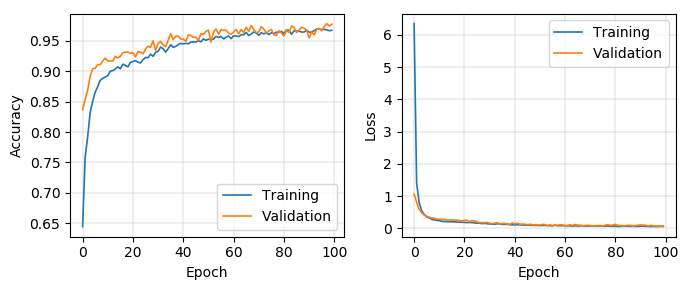

In [17]:
if 'accuracy' in h.history:
    train_acc = h.history['accuracy']
    val_acc = h.history['val_accuracy']
else:
    train_acc = h.history['acc']
    val_acc = h.history['val_acc']

train_loss = h.history['loss']
val_loss = h.history['val_loss']

fig = plt.figure(figsize=(7, 3), dpi=100)
ax = fig.add_subplot(121)
ax.plot(train_acc, label='Training', linewidth=1.2)
ax.plot(val_acc, label='Validation', linewidth=1.2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.legend(loc='best')
ax.grid(True, linewidth=.3)

ax2 = fig.add_subplot(122)
ax2.plot(train_loss, label='Training', linewidth=1.2)
ax2.plot(val_loss, label='Validation', linewidth=1.2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend(loc='best')
ax2.grid(True, linewidth=.3)
plt.tight_layout()

#### Confusion matrices with score threshold=0.5

In [18]:
def plot_confusion_matrix(y_true, y_pred, classes,
                          normalize=False,
                          title=None,
                          cmap=plt.cm.Blues,
                          colorbar=False,
                          savefig=False):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if title is not None:
        if normalize:
            title = 'Normalized confusion matrix'
        else:
            title = 'Confusion matrix, without normalization'

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    # Only use the labels that appear in the data
#     print(unique_labels(y_true, y_pred))
#     classes = classes[unique_labels(y_true, y_pred)]
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    fig, ax = plt.subplots(dpi=70)
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    if colorbar:
        ax.figure.colorbar(im, ax=ax)
    # We want to show all ticks...
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           # ... and label them with the respective list entries
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='True label',
           xlabel='Predicted label')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
#     fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f'{cm[i, j]:.1f}%' if normalize else f'{cm[i, j]:d}', #format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black",
                    size=20)
    fig.tight_layout()
    
    if savefig:
        plt.tight_layout()
        plt.savefig(savefig, dpi=300)
    
    return ax

Confusion matrix:
[[327  25]
 [ 13 791]]
Normalized confusion matrix:
[[0.92897727 0.07102273]
 [0.01616915 0.98383085]]
Confusion matrix, without normalization
[[327  25]
 [ 13 791]]
Normalized confusion matrix
[[92.89772727  7.10227273]
 [ 1.61691542 98.38308458]]


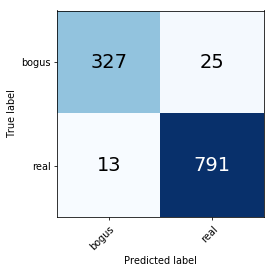

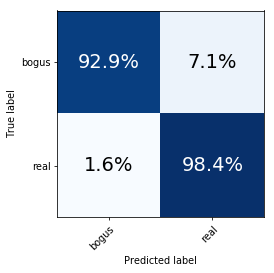

In [19]:
confusion_matr = confusion_matrix(y_test, labels_pred)
confusion_matr_normalized = confusion_matr.astype('float') / confusion_matr.sum(axis=1)[:, np.newaxis]

print('Confusion matrix:')
print(confusion_matr)

print('Normalized confusion matrix:')
print(confusion_matr_normalized)

# plot:
t_set = 'test'
plot_confusion_matrix(y_true=df.label.values[masks[t_set]], y_pred=labels_pred, 
                      classes=['bogus', 'real'],
                      normalize=False,
                      title=None,
                      cmap=plt.cm.Blues)
plot_confusion_matrix(y_true=df.label.values[masks[t_set]], y_pred=labels_pred, 
                      classes=['bogus', 'real'],
                      normalize=True,
                      title=None,
                      cmap=plt.cm.Blues)

#### FNR vs FPR

0.5 1.616915422885564 7.102272727271952


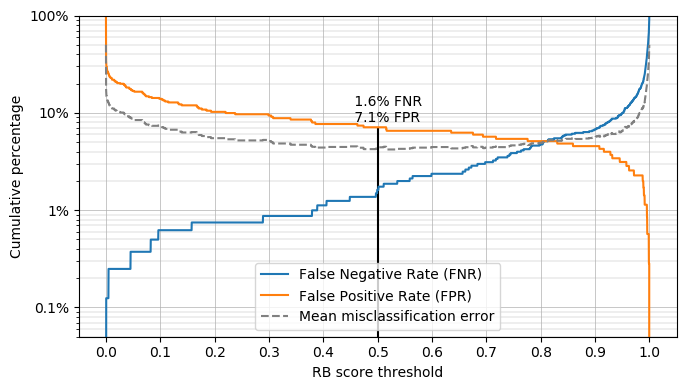

In [20]:
rbbins = np.arange(-0.0001, 1.0001, 0.0001)
h_b, e_b = np.histogram(preds[(df.label[masks['test']] == 0).values], bins=rbbins, density=True)
h_b_c = np.cumsum(h_b)
h_r, e_r = np.histogram(preds[(df.label[masks['test']] == 1).values], bins=rbbins, density=True)
h_r_c = np.cumsum(h_r)

# h_b, e_b

fig = plt.figure(figsize=(7, 4), dpi=100)
ax = fig.add_subplot(111)

rb_thres = np.array(list(range(len(h_b)))) / len(h_b)

ax.plot(rb_thres, h_r_c/np.max(h_r_c), 
        label='False Negative Rate (FNR)', linewidth=1.5)
ax.plot(rb_thres, 1 - h_b_c/np.max(h_b_c), 
        label='False Positive Rate (FPR)', linewidth=1.5)

mmce = (h_r_c/np.max(h_r_c) + 1 - h_b_c/np.max(h_b_c))/2
ax.plot(rb_thres, mmce, '--',
        label='Mean misclassification error', color='gray', linewidth=1.5)

ax.set_xlim([-0.05, 1.05])

ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))

# vals = ax.get_yticks()
# ax.set_yticklabels(['{:,.0%}'.format(x) for x in vals])

ax.set_yscale('log')
ax.set_ylim([5e-4, 1])
vals = ax.get_yticks()
ax.set_yticklabels(['{:,.1%}'.format(x) if x < 0.01 else '{:,.0%}'.format(x) for x in vals])

# thresholds:
thrs = [0.5, ]
# thrs = [0.5, 0.74]
for t in thrs:
    m_t = rb_thres < t
    fnr = np.array(h_r_c/np.max(h_r_c))[m_t][-1]
    fpr = np.array(1 - h_b_c/np.max(h_b_c))[m_t][-1]
    print(t, fnr*100, fpr*100)
    # ax.vlines(t_1, 0, 1.1)
    ax.vlines(t, 0, max(fnr, fpr))
    ax.text(t - .05, max(fnr, fpr) + 0.01, f' {fnr*100:.1f}% FNR\n {fpr*100:.1f}% FPR', fontsize=10)

ax.set_xlabel('RB score threshold')
ax.set_ylabel('Cumulative percentage')
ax.legend(loc='lower center')
ax.grid(True, which='major', linewidth=.5)
ax.grid(True, which='minor', linewidth=.3)
plt.tight_layout()

#### ROC curve

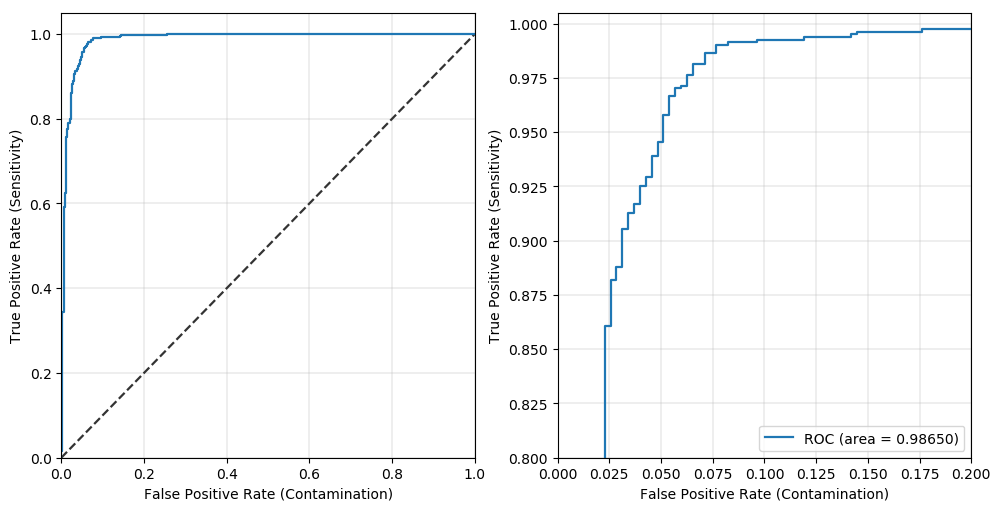

In [21]:
fig = plt.figure(figsize=(14, 5), dpi=100)
fig.subplots_adjust(bottom=0.09, left=0.05, right=0.70, top=0.98, wspace=0.2, hspace=0.2)
lw = 1.6
# ROCs
ax = fig.add_subplot(1, 2, 1)
# zoomed ROCs
ax2 = fig.add_subplot(1, 2, 2)

ax.plot([0, 1], [0, 1], color='#333333', lw=lw, linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (Contamination)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
# ax.legend(loc="lower right")
# ax.legend(loc="best")
ax.grid(True, linewidth=.3)

# ax2.set_xlim([0.0, .2])
# ax2.set_ylim([0.8, 1.0])
ax2.set_xlim([0.0, .2])
ax2.set_ylim([0.8, 1.005])
ax2.set_xlabel('False Positive Rate (Contamination)')
ax2.set_ylabel('True Positive Rate (Sensitivity)')
# ax.legend(loc="lower right")
ax2.grid(True, linewidth=.3)

fpr, tpr, thresholds = roc_curve(df['label'][masks['test']], preds)
roc_auc = auc(fpr, tpr)

ax.plot(fpr, tpr, lw=lw)
ax2.plot(fpr, tpr, lw=lw, label=f'ROC (area = {roc_auc:.5f})')
ax2.legend(loc="lower right")

#### Generate report

In [22]:
# generate training report in json format
print('Generating report...')
r = {'Run time stamp': run_t_stamp,
     'Model name': model_name,
     'Model trained': 'vgg6',
     'Batch size': batch_size,
     'Optimizer': optimizer,
     'Requested number of train epochs': epochs,
     'Early stopping after epochs': patience,
     'Training+validation/test split': test_split,
     'Training/validation split': validation_split,
     'Weight training data by class': class_weight,
     'Random state': random_state,
     'Number of training examples': x_train.shape[0],
     'Number of test examples': x_test.shape[0],
     'X_train shape': x_train.shape,
     'Y_train shape': y_train.shape,
     'X_test shape': x_test.shape,
     'Y_test shape': y_test.shape,
     'Data augmentation': data_augmentation,
     'Test loss': test_loss,
     'Test accuracy': test_accuracy,
     'Confusion matrix': confusion_matr.tolist(),
     'Normalized confusion matrix': confusion_matr_normalized.tolist(),
     'Misclassified test candids': list(misclassifications_test.keys()),
     'Misclassified training candids': list(misclassifications_train.keys()),
     'Test misclassifications': misclassifications_test,
     'Training misclassifications': misclassifications_train,
     'Training history': h.history
     }
for k in r['Training history'].keys():
    r['Training history'][k] = np.array(r['Training history'][k]).tolist()

# print(r)

save_report(path='./', stamp=run_t_stamp, report=r)
print('Done.')

Generating report...
Done.


### Some real data

In [23]:
def plot_triplet(tr):
    fig = plt.figure(figsize=(8, 2), dpi=100)
    ax = fig.add_subplot(131)
    ax.axis('off')
    ax.imshow(tr[:, :, 0], origin='upper', cmap=plt.cm.bone)
    ax2 = fig.add_subplot(132)
    ax2.axis('off')
    ax2.imshow(tr[:, :, 1], origin='upper', cmap=plt.cm.bone)
    ax3 = fig.add_subplot(133)
    ax3.axis('off')
    ax3.imshow(tr[:, :, 2], origin='upper', cmap=plt.cm.bone)
    plt.show()

In [24]:
#!wget -O 714287740515015072.json https://raw.githubusercontent.com/dmitryduev/braai/master/nb/714287740515015072.json
#!wget -O 893215910715010007.json https://raw.githubusercontent.com/dmitryduev/braai/master/nb/893215910715010007.json

0.4333333373069763


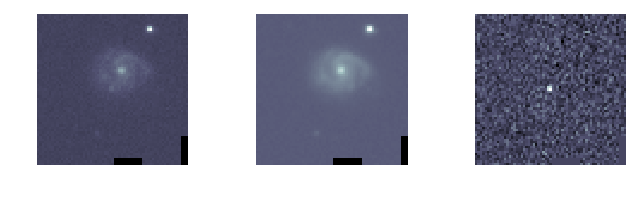

array([[0.98361546]], dtype=float32)

In [25]:
with open('714287740515015072.json', 'r') as f:
    al = json.load(f)
print(al['candidate']['rb'])
tr = make_triplet(al)
plot_triplet(tr)
model.predict(np.expand_dims(tr, axis=0))

0.04857143014669418


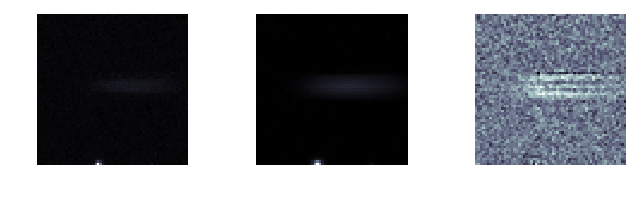

array([[0.00022069]], dtype=float32)

In [26]:
with open('893215910715010007.json', 'r') as f:
    al = json.load(f)
print(al['candidate']['rb'])
tr = make_triplet(al)
plot_triplet(tr)
model.predict(np.expand_dims(tr, axis=0))